In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.partial_sc import partial_sc


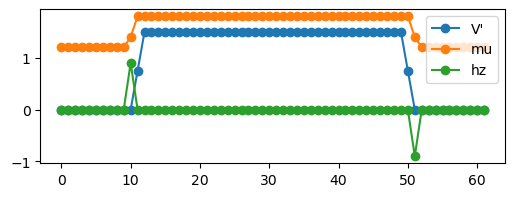

In [2]:
widthD = 10
widthF = 1
widthP = 40

X, Y = widthD+widthF+widthP+widthF+widthD, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
muN = 1.2 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muN
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:widthD + widthF + widthP] = muP
mu[widthD + widthF + widthP:widthD + widthF + widthP + widthF] = muF
mu[widthD + widthF + widthP + widthF:widthD + widthF + widthP + widthF + widthD] = muN

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0
h[widthD + widthF + widthP + widthF-1] = -h0


V = None

U0 = 1.5 * t
U = U0 * np.ones(lattice.X)
U[widthD:-widthD] = 0
U[widthD-1] = U0/2
U[-widthD] = U0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD+widthP:] = 0
V_prime[widthF+widthD] = V_prime0/2
V_prime[widthF+widthD+widthP-1] = V_prime0/2

plt.figure(figsize=(6,2))
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')
# plt.xlim(85,100)
# plt.xlim(0,15)


plt.legend()

In [3]:
from scripts.utils import is_hermitian

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F0_init=0.12,
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j],
                hx=h)

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_kindep()))


True
True
True


In [4]:
fixed_sites = (V_prime == 0)
fixed_syms = ["F0"]
partial_sc(H, temperature=T,
           fixed_sites=fixed_sites,
           fixed_syms=fixed_syms,
           atol=1e-3, rtol=1e-1, maxiter=500, 
           verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.020335309509963498
Relative error: 20335309509.9635
Average old: (0.03870967741935484+0j)
Average: (0.04062246415254584+0j)
F_xplus:
Absolute error: 0.0704925113969675
Relative error: 70492511396.96748
Average old: 0j
Average: (-0.00526797632427039+0j)
F_xmin:
Absolute error: 0.07049572644483748
Relative error: 70495726444.83748
Average old: 0j
Average: (-0.005267334543208259+0j)
F_yplus:
Absolute error: 0.08230012245744928
Relative error: 82300122457.44928
Average old: 0j
Average: (-0.007016089801138478+2.026900884468454e-06j)
F_ymin:
Absolute error: 0.08230012245744928
Relative error: 82300122457.44928
Average old: 0j
Average: (-0.007016089801138478-2.026900884468454e-06j)
Fuu_xplus:
Absolute error: 0.025957111913534423
Relative error: 21060291172.57482
Average old: (0.006557377049180328+0j)
Average: (0.009202466412586003+0j)
Fuu_xmin:
Absolute error: 0.02595454059922399
Relative error: 21055992125.640285
Average old: (-0.006557377049180328+0j)
Average: (-0.0092

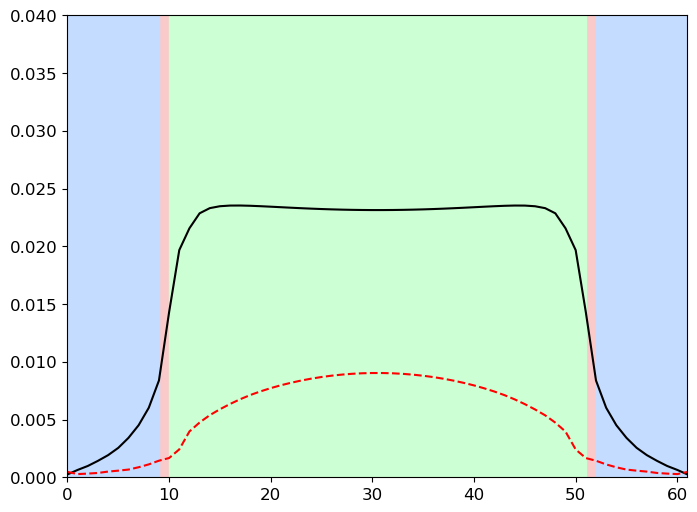

0.023135695061952906


In [5]:
x = np.arange(0, widthD + widthF + widthP+ widthF + widthD)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"U/t = {U0}, V'/t={V_prime0}, T/t={T}, hx/t={h0}")

axs.axvspan(widthD - 1, widthD, color='#FACACA')
axs.axvspan(0, widthD - 1, color='#C4DCFF')

axs.axvspan(widthD + widthF + widthP, widthD + widthF + widthP+1, color='#FACACA')
axs.axvspan(widthD + widthF-1, widthD + widthF + widthP, color='#CCFFD3')
axs.axvspan(widthD + widthF + widthP + widthF,  widthD + widthF + widthP+ widthF + widthD, color='#C4DCFF')

# axs.plot(x, np.real(H.F0), label="onsite")
# axs.plot(x, np.real(F.dwave), label="F.dwave")
# axs.plot(x, np.real(F.swave), label="F.swave")

# axs.plot(x, np.real(F.px), label="ud:p_x-wave")
# axs.plot(x, np.imag(F.py), "--", label="ud:p_y-wave")

axs.plot(x, np.real(Fuu.px-Fdd.px)/2, label="uu:p_x-wave", color='black')
axs.plot(x, np.imag(Fuu.py+Fdd.py)/2, "--", label="uu:p_y-wave", color='red')
# axs.set_xlabel("x", fontsize=15)

# axs.set_yticks([])

axs.tick_params(axis='both', labelsize=12)

axs.set_ylim(0.0, 0.04)
axs.set_xlim(0.0, 61)


# axs.legend(fontsize=16, loc='center')

plt.savefig("../figures/SFPFS.svg", bbox_inches='tight')
plt.show()

print(np.real(Fuu.px-Fdd.px)[30]/2)

In [6]:
print(Fuu.px[30])
print(Fuu.py[30])


(0.023177245612379747-6.788842307417021e-09j)
(8.602376520014061e-09+0.008817768366945374j)
